# The follow up to `distributions.qmd`, due to easier graphing with ipynb format

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from pyhere import here
import itertools
import seaborn as sns

In [ ]:
phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))
phot['e_F8'].describe()

count    3417.000000
mean        0.475028
std         5.502403
min         0.017300
25%         0.146600
50%         0.245200
75%         0.392700
max       276.468200
Name: e_F8, dtype: float64

## Uncertainty distributions

c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 60'. Pick better value with 'binwidth'.


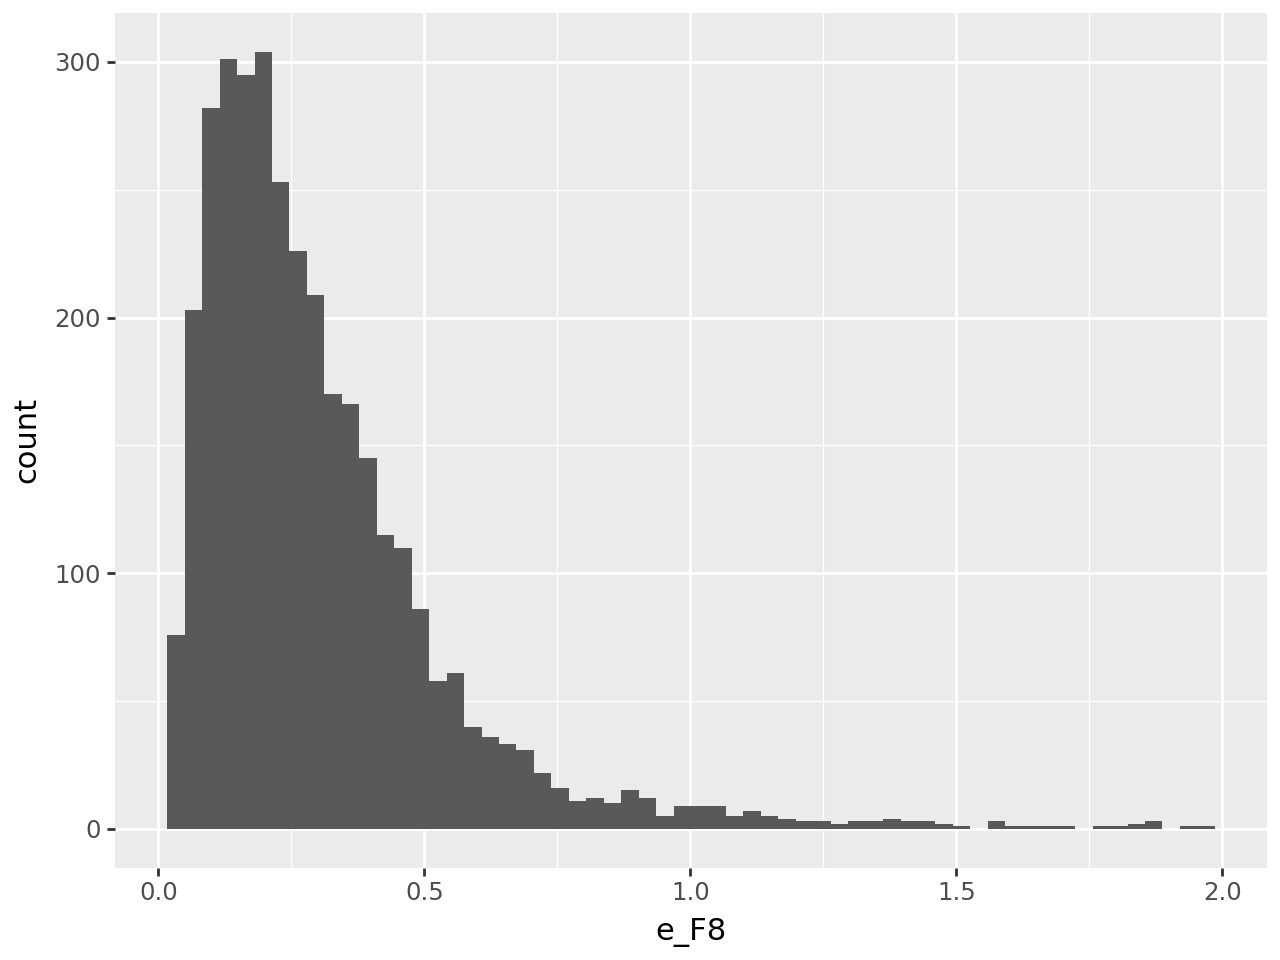

In [ ]:
unc_df = phot.copy()
unc_df = unc_df[['e_F8','e_F12', 'e_F24', 'e_F70']]
ef8_df = unc_df[unc_df['e_F8'] < 2]
e8 = (
    ggplot(ef8_df, aes(x='e_F8')) +
    geom_histogram()
)
e8

c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 60'. Pick better value with 'binwidth'.


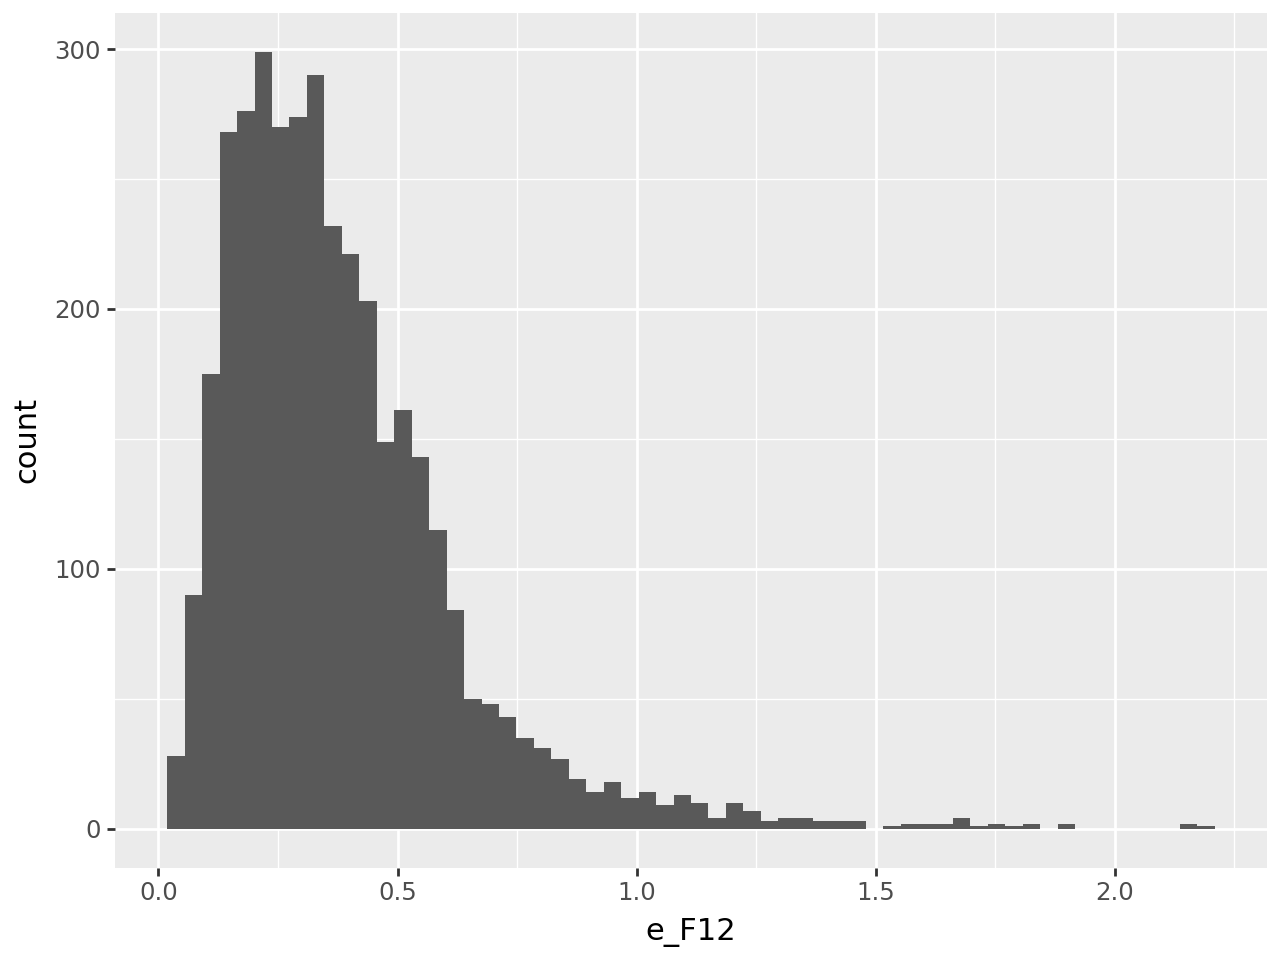

In [ ]:
ef12_df = unc_df[unc_df['e_F12'] < 5]
e12 = (
    ggplot(ef12_df, aes(x='e_F12')) +
    geom_histogram()
)
e12

c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 76'. Pick better value with 'binwidth'.


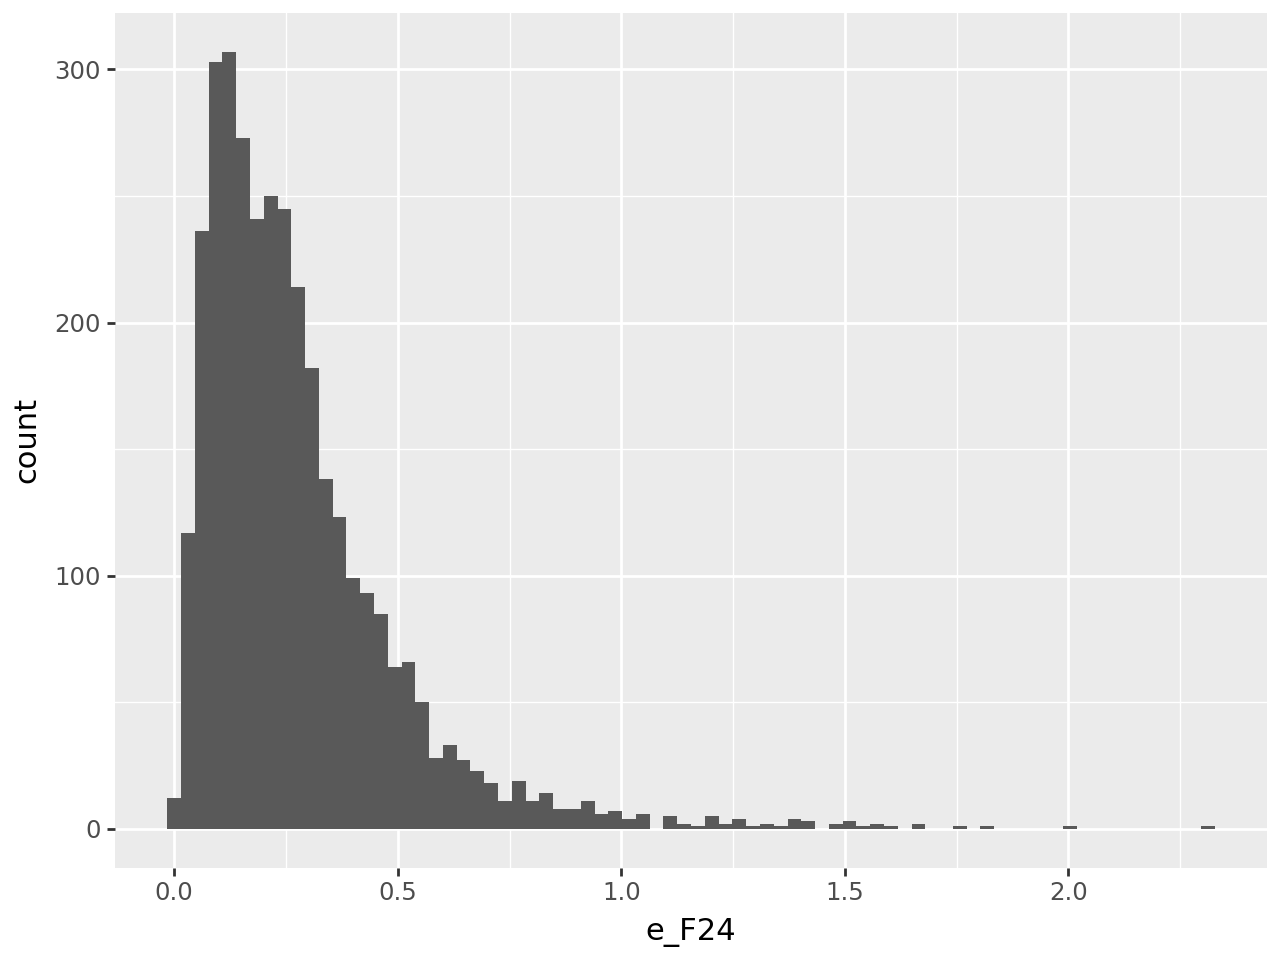

In [ ]:
ef24_df = unc_df[unc_df['e_F24'] < 5]
(
    ggplot(ef24_df, aes(x='e_F24')) +
    geom_histogram()
)

c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 130'. Pick better value with 'binwidth'.
c:\Users\alexe\miniforge3\envs\math4025\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 450 rows containing non-finite values.


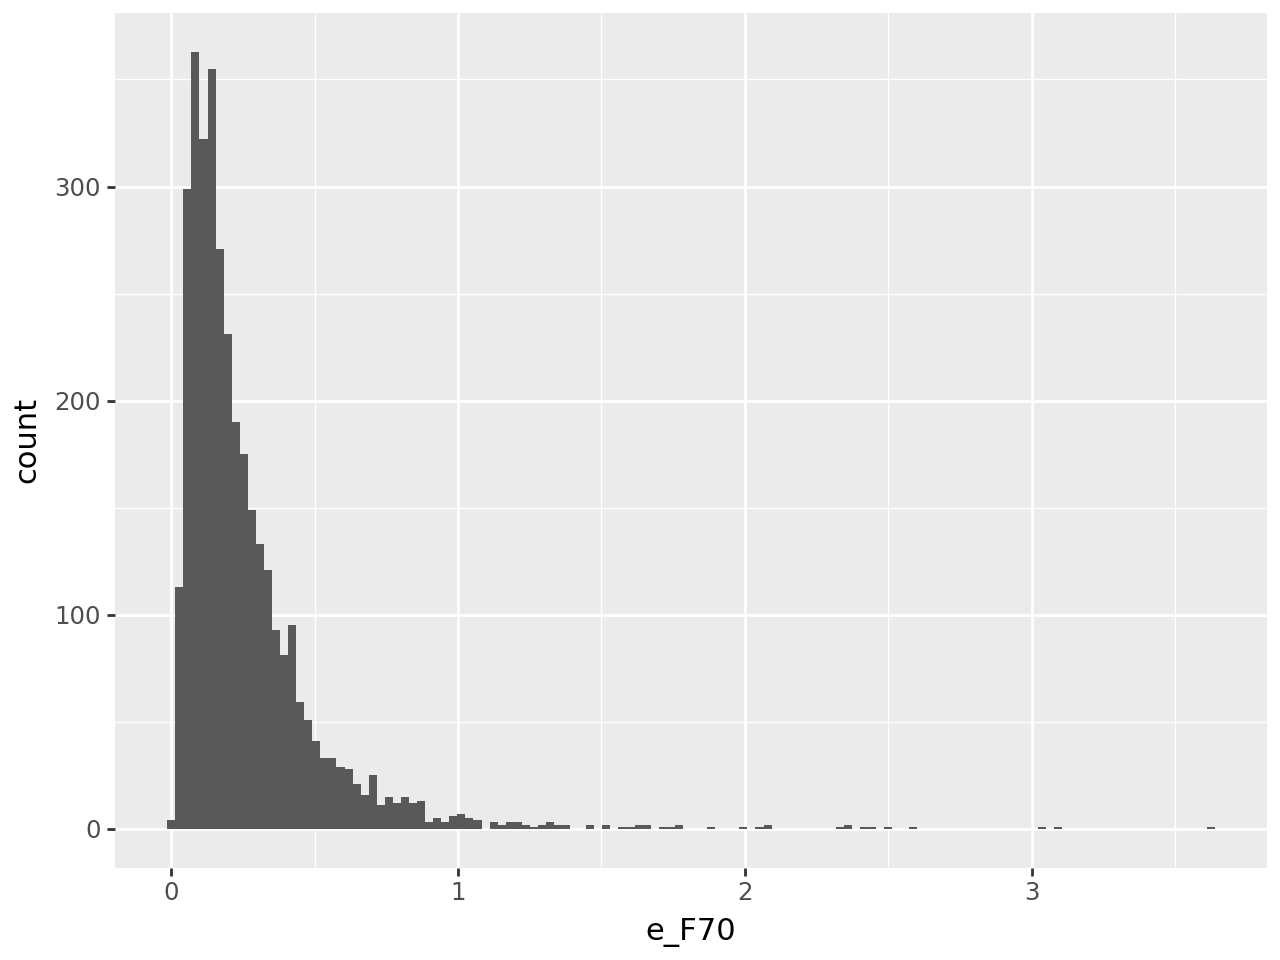

In [ ]:
ef70_df = unc_df.copy()
(
    ggplot(ef70_df, aes(x='e_F70')) +
    geom_histogram()
)

In [ ]:
print(unc_df['e_F8'].describe())

count    3417.000000
mean        0.475028
std         5.502403
min         0.017300
25%         0.146600
50%         0.245200
75%         0.392700
max       276.468200
Name: e_F8, dtype: float64


In [ ]:
print(unc_df['e_F12'].describe())


count    3686.000000
mean        0.398546
std         0.841363
min         0.023800
25%         0.210525
50%         0.330500
75%         0.490000
max        48.000900
Name: e_F12, dtype: float64


In [ ]:
print(unc_df['e_F24'].describe())

count    3379.000000
mean        0.297631
std         0.918956
min         0.009900
25%         0.126800
50%         0.225300
75%         0.357650
max        50.086400
Name: e_F24, dtype: float64


In [ ]:
print(unc_df['e_F70'].describe())

count    3494.000000
mean        0.260632
std         0.265292
min         0.011500
25%         0.105425
50%         0.184400
75%         0.326700
max         3.635800
Name: e_F70, dtype: float64


Correlation Matrix:
            e_F8     e_F12     e_F24     e_F70
e_F8   1.000000  0.569930  0.048596  0.068002
e_F12  0.569930  1.000000  0.298374  0.164071
e_F24  0.048596  0.298374  1.000000  0.132901
e_F70  0.068002  0.164071  0.132901  1.000000


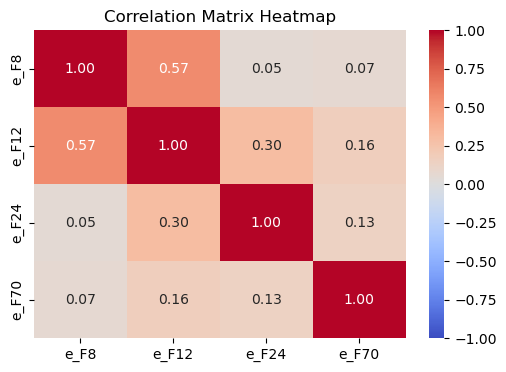

In [ ]:
corr_matrix = unc_df.corr(numeric_only=True)
print("Correlation Matrix:\n", corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()